# 03 Matching and Prediction

This notebook uses real held-out trajectories to inspect neighbor retrieval, history reranking, one-step forecasts, and short rollouts. The point is not only to show the API, but to reveal where the real data violate modeling assumptions.


## Goals

1. Build a real-data reference bank and hold out at least one real embryo for queries.
2. Compare position-only and history-aware matching on the held-out embryo.
3. Inspect the local increment cloud selected by the model.
4. Run a short rollout and compare it against the observed future on the real trajectory.


In [ ]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "dev" / "particle_prediction" / "data" / "loading.py").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dev.particle_prediction.data.loading import DEFAULT_BUILD_DIR, FILE_PREFIX, load_trajectories
from dev.particle_prediction.data.smoothing import smooth_trajectories
from dev.particle_prediction.data.resampling import resample_smoothed_trajectories
from dev.particle_prediction.data.transition_bank import build_transition_bank
from dev.particle_prediction.data.dataset import build_query_from_resampled_trajectory
from dev.particle_prediction.models.local_transition_pf import LocalTransitionPredictor
from dev.particle_prediction.models.matching import MatchingConfig, compare_matching_modes
from dev.particle_prediction.viz.matching import (
    compare_default_vs_fast_matching,
    plot_history_offset_heatmap,
    plot_history_reranking,
)
from dev.particle_prediction.viz.prediction import (
    plot_local_increment_cloud,
    plot_sampled_next_steps,
    plot_support_diagnostics_along_rollout,
)

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

def resolve_real_data_context(max_default_trajectories=100):
    build_dir = Path(os.environ.get("MORPHSEQ_PARTICLE_BUILD_DIR", project_root / DEFAULT_BUILD_DIR))
    if not build_dir.exists():
        raise FileNotFoundError(
            f"Expected real data under {build_dir}. Set MORPHSEQ_PARTICLE_BUILD_DIR to override."
        )

    available_experiments = sorted(
        path.stem[len(FILE_PREFIX):]
        for path in build_dir.glob(f"{FILE_PREFIX}*.csv")
    )
    if not available_experiments:
        raise FileNotFoundError(f"No {FILE_PREFIX}*.csv files found in {build_dir}")

    env_experiments = os.environ.get("MORPHSEQ_PARTICLE_EXPERIMENTS")
    experiment_ids = [part.strip() for part in env_experiments.split(",") if part.strip()] if env_experiments else [available_experiments[0]]
    env_limit = os.environ.get("MORPHSEQ_PARTICLE_MAX_TRAJECTORIES")
    max_trajectories = int(env_limit) if env_limit else max_default_trajectories
    return build_dir, available_experiments, experiment_ids, max_trajectories

build_dir, available_experiments, experiment_ids, max_trajectories = resolve_real_data_context()
print(f"Project root: {project_root}")
print(f"Build dir: {build_dir}")
print(f"Available experiments: {available_experiments[:5]}{' ...' if len(available_experiments) > 5 else ''}")
print(f"Notebook experiments: {experiment_ids}")
print(f"Trajectory cap: {max_trajectories}")

Project root: /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq
Build dir: /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/morphseq_playground/metadata/build06_output
Available experiments: ['20230525', '20230531', '20230613', '20230615', '20230622'] ...
Notebook experiments: ['20230525']
Trajectory cap: 100


In [23]:
# available_experiments

In [24]:
experiment_ids = ['20231218']
dataset = load_trajectories(
    build_dir=build_dir,
    experiment_ids=experiment_ids,
    n_components=10,
    scale=True,
    min_trajectory_length=5,
    verbose=False,
)
selected_trajectories = dataset.trajectories[:max_trajectories]
summary_df = pd.DataFrame(
    {
        "embryo_id": [traj.embryo_id for traj in selected_trajectories],
        "experiment_id": [traj.experiment_id for traj in selected_trajectories],
        "perturbation_class": [traj.perturbation_class for traj in selected_trajectories],
        "n_frames": [len(traj.time_seconds) for traj in selected_trajectories],
        "delta_t": [traj.delta_t for traj in selected_trajectories],
        "n_hard_gaps": [int(np.sum(traj.hard_gap_mask)) if traj.hard_gap_mask is not None else 0 for traj in selected_trajectories],
        "n_interpolatable_gaps": [int(np.sum(traj.interpolatable_gap_mask)) if traj.interpolatable_gap_mask is not None else 0 for traj in selected_trajectories],
    }
)
print(f"Loaded {len(dataset.trajectories)} trajectories; using first {len(selected_trajectories)} for the notebook walkthrough.")
summary_df.head(10)


Loaded 67 trajectories; using first 67 for the notebook walkthrough.


,embryo_id,experiment_id,perturbation_class,n_frames,delta_t,n_hard_gaps,n_interpolatable_gaps
0,20231218_A01_e01,20231218,wik,34,2688.5265,0,0
1,20231218_A02_e01,20231218,wik,27,2688.5265,0,0
2,20231218_A03_e01,20231218,Uncertain,6,2688.5265,0,0
3,20231218_A04_e01,20231218,tbxta,34,2688.5265,0,0
4,20231218_A08_e01,20231218,tbxta,34,2688.5265,0,0
5,20231218_A09_e01,20231218,Uncertain,5,2688.5265,0,0
6,20231218_A11_e01,20231218,tbxta,9,2688.5265,0,1
7,20231218_B01_e01,20231218,wik,34,2688.5265,0,0
8,20231218_B05_e01,20231218,tbxta,7,2688.5265,0,2
9,20231218_B06_e01,20231218,tbxta,34,2688.5265,0,0


In [25]:
window_seconds = 5.0 * 3600.0
poly_order = 2
delta_s = 0.25
history_length = 5
smoothed_subset = smooth_trajectories(selected_trajectories, window_seconds=window_seconds, poly_order=poly_order)
resampled_subset = resample_smoothed_trajectories(smoothed_subset, delta_s=delta_s)
if len(resampled_subset) < 3:
    raise ValueError("Need at least three trajectories for a simple holdout walkthrough.")
reference_trajectories = resampled_subset[:-1]
heldout_trajectory = resampled_subset[-1]
bank = build_transition_bank(reference_trajectories, history_length=history_length + 2, use_state_index=True)
print(f"Reference trajectories: {len(reference_trajectories)} | Held out: {heldout_trajectory.source.embryo_id} | Bank windows: {len(bank)}")


Reference trajectories: 66 | Held out: 20231218_H12_e01 | Bank windows: 10568


## Build Real Queries from the Held-Out Embryo


In [ ]:
state_index = min(max(history_length + 2, 64), len(heldout_trajectory.resampled) - 4)
requested_rollout_steps = 25
n_rollout_steps = min(requested_rollout_steps, len(heldout_trajectory.resampled) - state_index - 1)
snapshot_query = build_query_from_resampled_trajectory(heldout_trajectory, state_index=state_index, history_length=None)
history_query = build_query_from_resampled_trajectory(heldout_trajectory, state_index=state_index, history_length=history_length)
true_future = heldout_trajectory.resampled[state_index + 1 : state_index + 1 + n_rollout_steps]
context_points = heldout_trajectory.resampled[state_index - history_length : state_index + 1]
print(snapshot_query.metadata)
print(history_query.metadata)
print(f"Rollout steps synced to available truth window: {n_rollout_steps}")

{'embryo_id': '20231218_H12_e01', 'experiment_id': '20231218', 'perturbation_class': 'tbxta', 'resampled_index': 64, 'arc_length_value': 16.0, 'source_time_estimate': 59868.48966242631}
{'embryo_id': '20231218_H12_e01', 'experiment_id': '20231218', 'perturbation_class': 'tbxta', 'resampled_index': 64, 'arc_length_value': 16.0, 'source_time_estimate': 59868.48966242631}


In [ ]:
fig, axis = plt.subplots(figsize=(7.2, 5.8))
for trajectory in reference_trajectories:
    axis.plot(
        trajectory.resampled[:, 0],
        trajectory.resampled[:, 1],
        color="0.75",
        linewidth=1.0,
        alpha=0.35,
    )
axis.plot(
    heldout_trajectory.resampled[:, 0],
    heldout_trajectory.resampled[:, 1],
    color="0.15",
    linewidth=2.0,
    label="held-out trajectory",
)
axis.scatter(
    context_points[:-1, 0],
    context_points[:-1, 1],
    s=24,
    facecolors="white",
    edgecolors="0.2",
    linewidths=0.8,
    label="query context",
)
axis.scatter(
    history_query.current_state[0],
    history_query.current_state[1],
    color="tab:red",
    marker="x",
    s=80,
    label="query",
)
axis.set_xlabel("latent dim 0")
axis.set_ylabel("latent dim 1")
axis.set_title("Full held-out and reference trajectories")
axis.grid(alpha=0.2)
axis.legend(frameon=False)
fig.tight_layout()

In [ ]:
print("Query resampled index:", history_query.metadata["resampled_index"])
print("Reference bank windows:", len(bank))
print("Held-out embryo:", heldout_trajectory.source.embryo_id)

k_state: 128
bank windows: 10568
returned candidates: 128


## Matching Diagnostics on Real Data


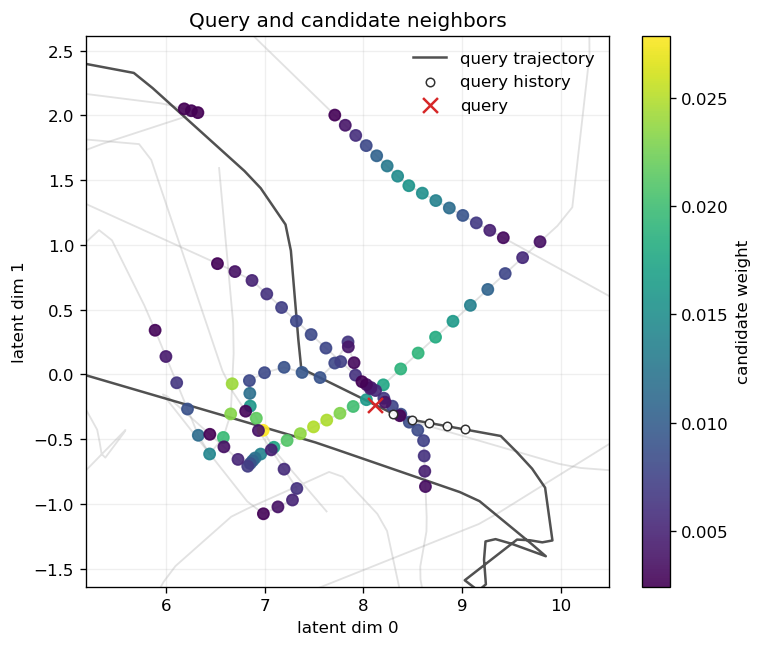

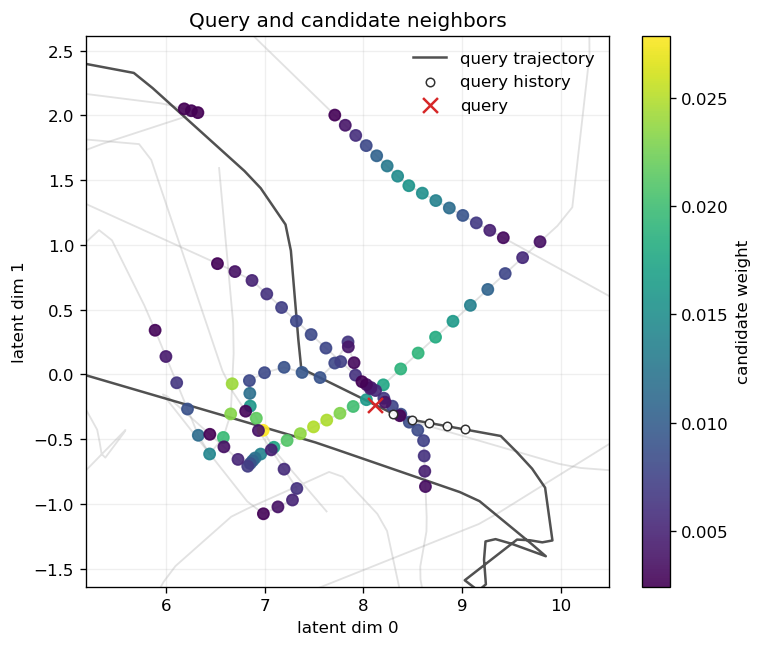

In [ ]:
import importlib
import dev.particle_prediction.viz.matching as matching_viz

importlib.reload(matching_viz)
from dev.particle_prediction.viz.matching import (
    plot_query_and_candidate_neighbors,
    plot_reference_distance_landscape,
)

matching_config = MatchingConfig(k_state=128, offset_radius=3, retrieval_method="nn")
matches = compare_matching_modes(
    bank,
    history_query.current_state,
    history_query.history_segments,
    config=matching_config,
 )
print("k_state:", matching_config.k_state)
print("bank windows:", len(bank))
print("returned candidates:", len(matches["default"].candidate_indices))
plot_query_and_candidate_neighbors(
    history_query.current_state,
    matches["default"],
    query_trajectory=heldout_trajectory.resampled,
    query_history_points=context_points,
    reference_trajectories={traj.source.embryo_id: traj.resampled for traj in reference_trajectories},
    max_candidates=100,
)

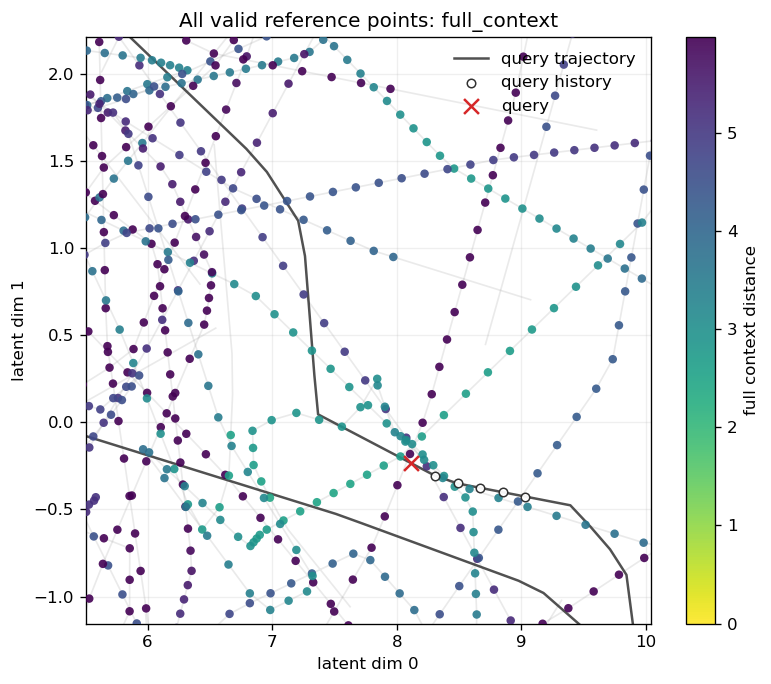

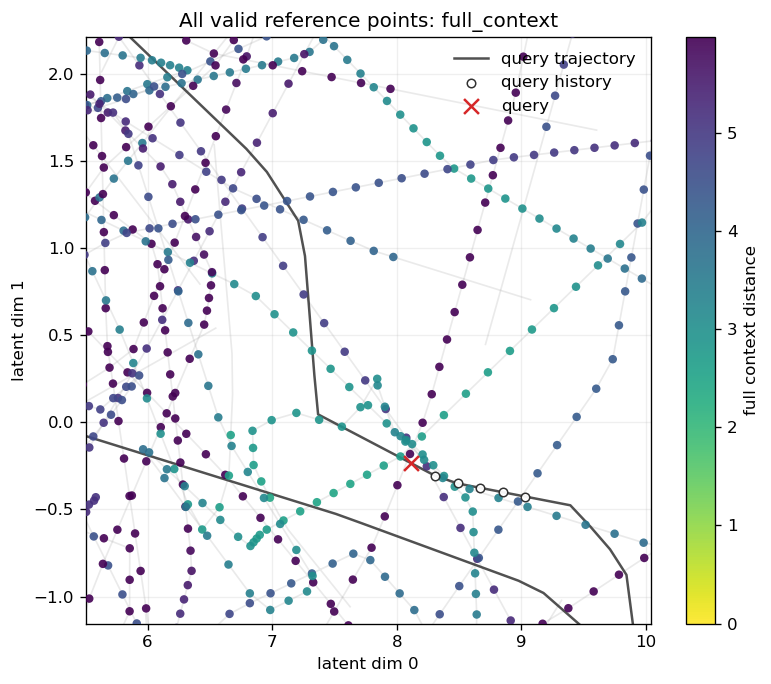

In [63]:
distance_metric = "full_context"  # options: 'full_context', 'context_2d', 'state_only'

plot_reference_distance_landscape(
    history_query.current_state,
    bank,
    query_trajectory=heldout_trajectory.resampled,
    query_history_points=context_points,
    query_history_segments=history_query.history_segments,
    reference_trajectories={traj.source.embryo_id: traj.resampled for traj in reference_trajectories},
    metric=distance_metric,
)

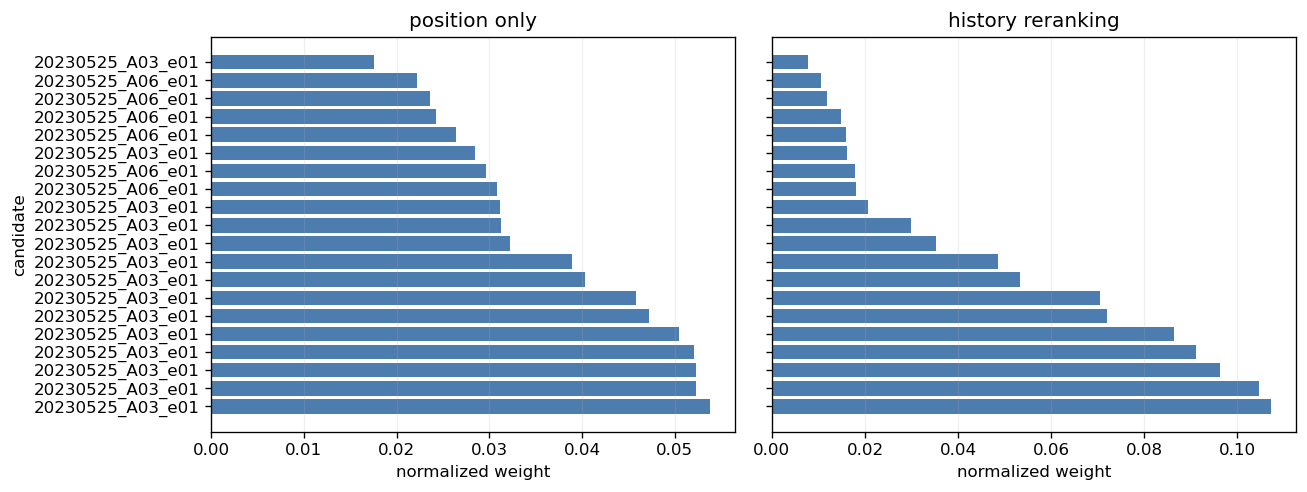

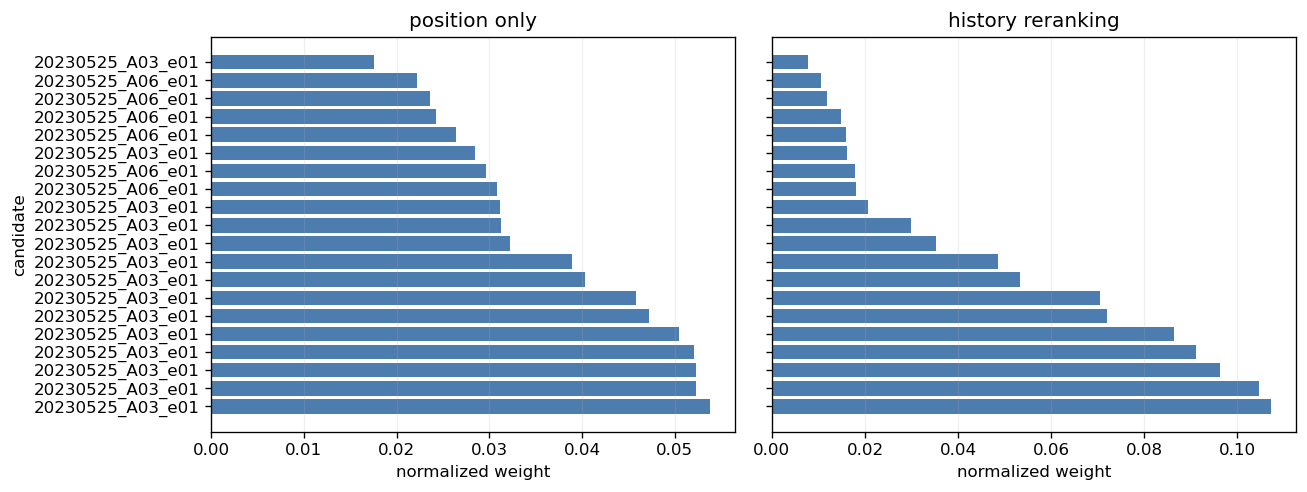

In [46]:
plot_history_reranking(matches["default"], matches["fast_summary"])


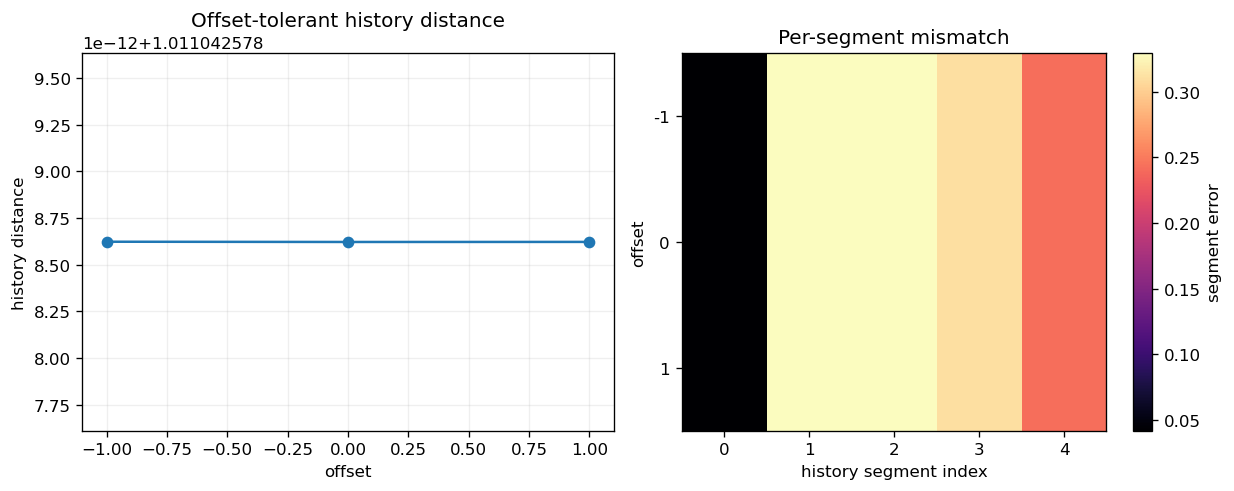

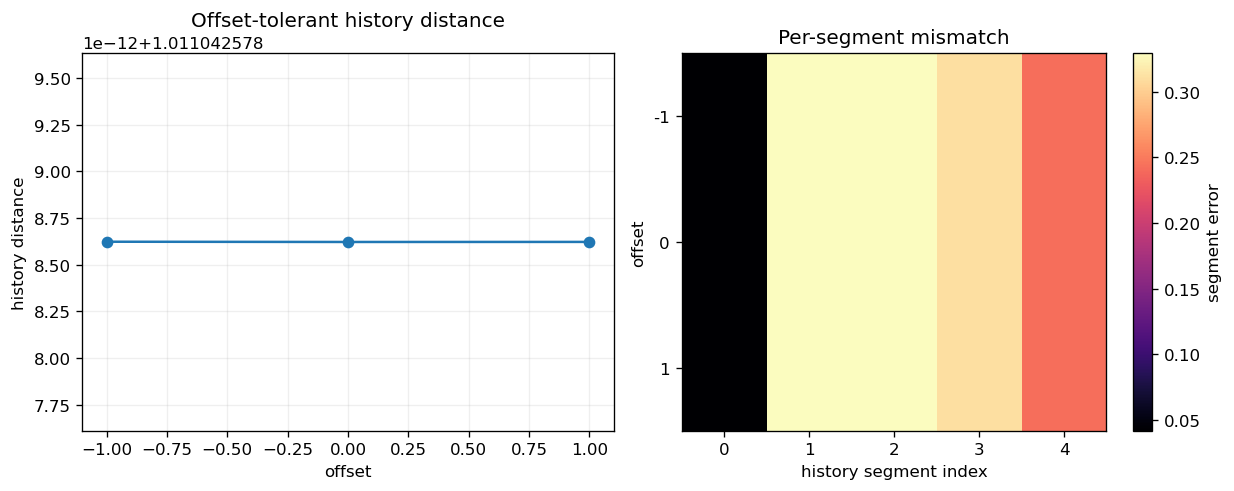

In [50]:
plot_history_offset_heatmap(
    history_query.history_segments,
    bank.windows[matches["default"].candidate_indices[0]],
    offset_radius=matching_config.offset_radius,
)

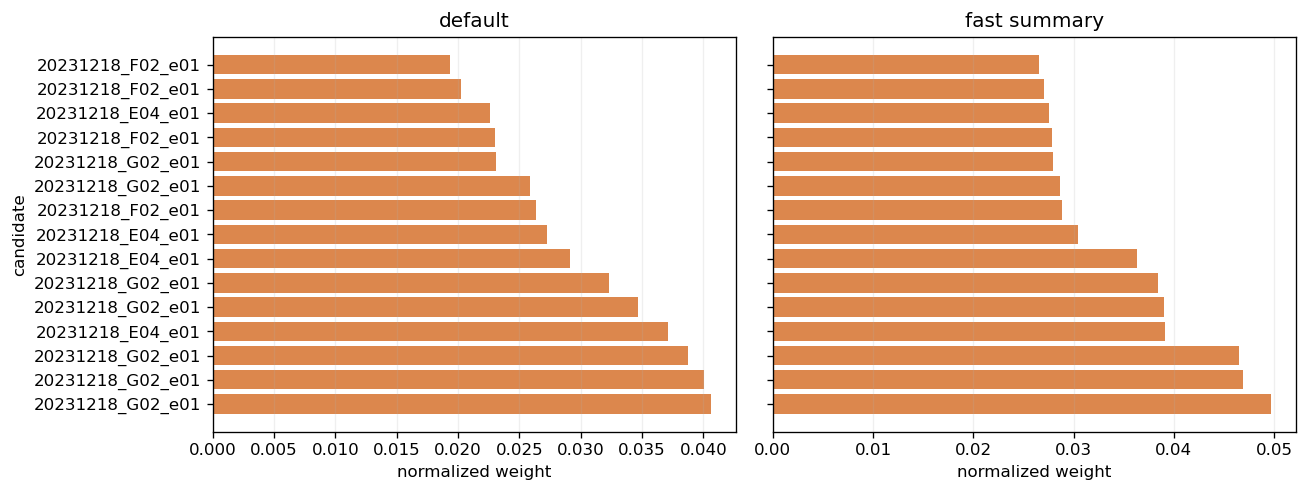

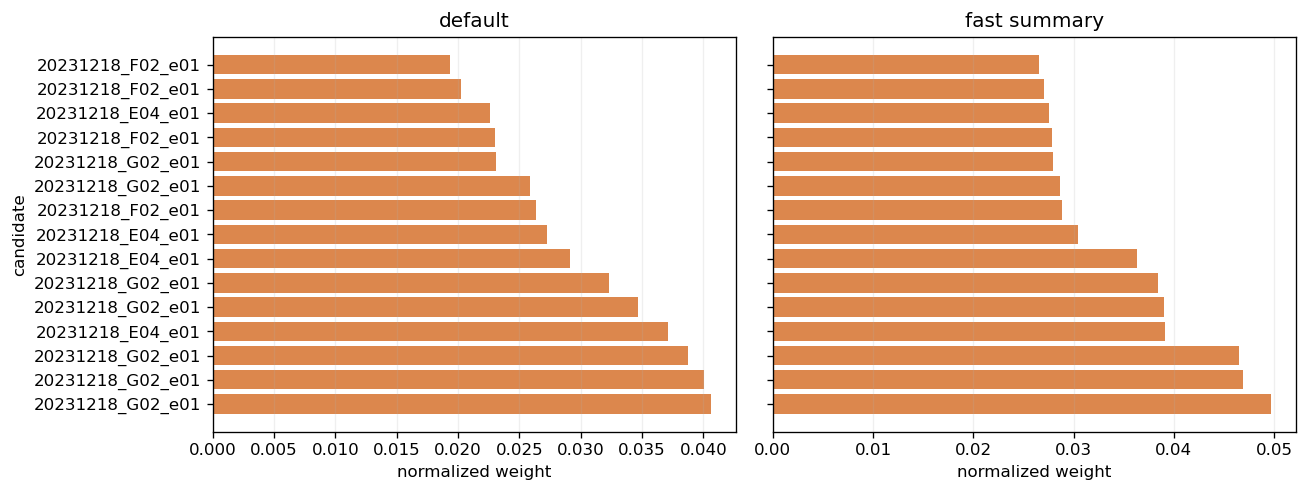

In [47]:
compare_default_vs_fast_matching(matches["default"], matches["fast_summary"])

## One-Step and Rollout Prediction


In [ ]:
predictor = LocalTransitionPredictor(
    bank=bank,
    matching_config=matching_config,
    sigma_parallel=0.75,
    sigma_perp=0.25,
    jitter_mode="tangent",
)
one_step = predictor.predict_query(history_query, n_samples=64, rng=np.random.default_rng(7))
rollout = predictor.rollout_query(history_query, n_steps=n_rollout_steps, n_particles=64, rng=np.random.default_rng(11))
one_step.diagnostics

{'query_mode': 'history',
 'jitter_mode': 'tangent',
 'sigma_parallel': 0.75,
 'sigma_perp': 0.25,
 'mean_score': 4.4810774169310825}

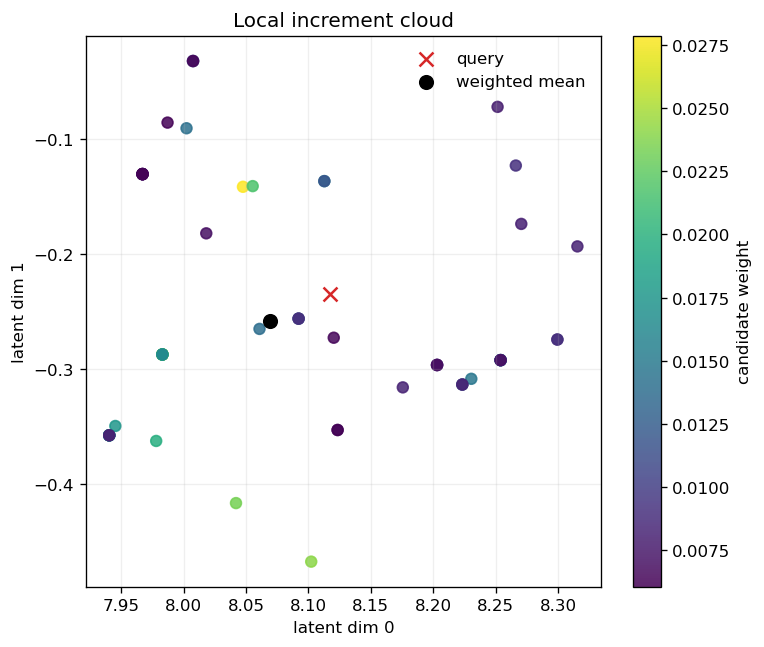

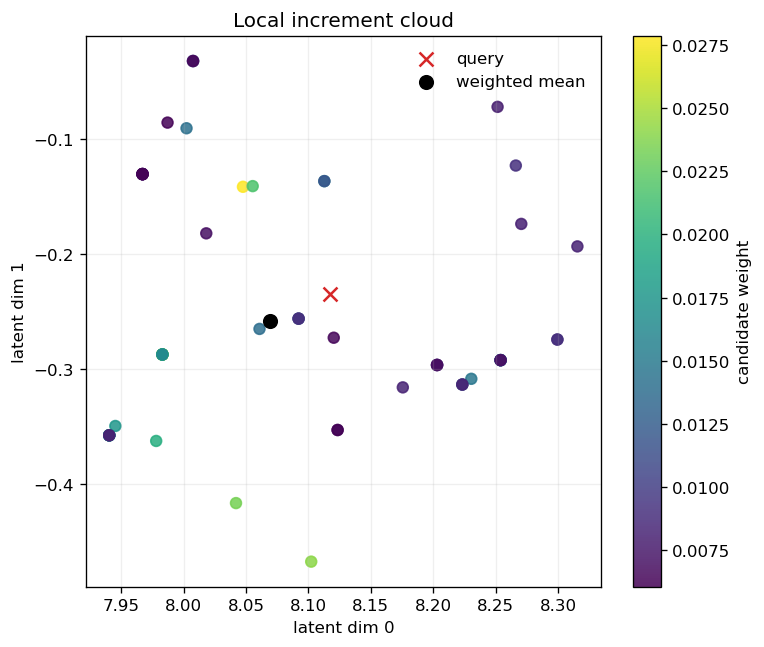

In [65]:
plot_local_increment_cloud(history_query.current_state, one_step)


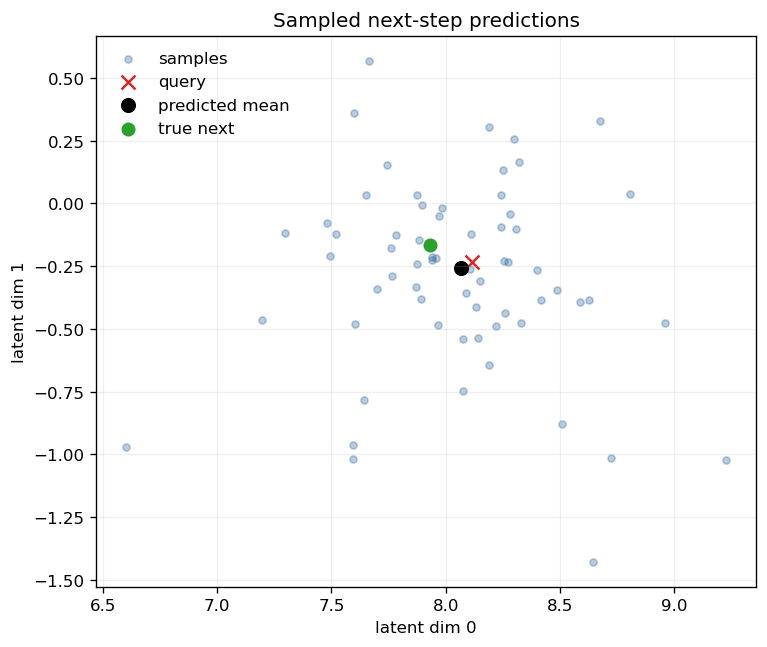

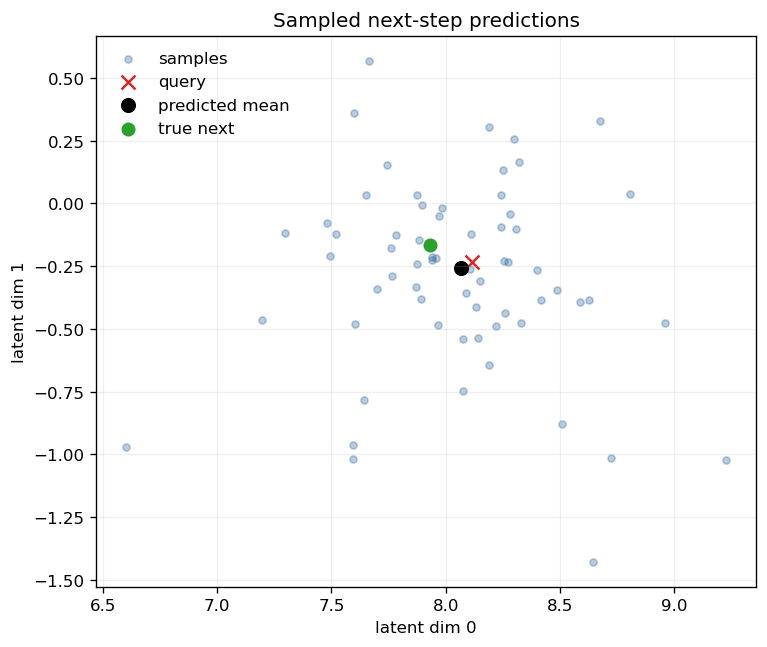

In [66]:
plot_sampled_next_steps(history_query.current_state, one_step, true_next_state=true_future[0])


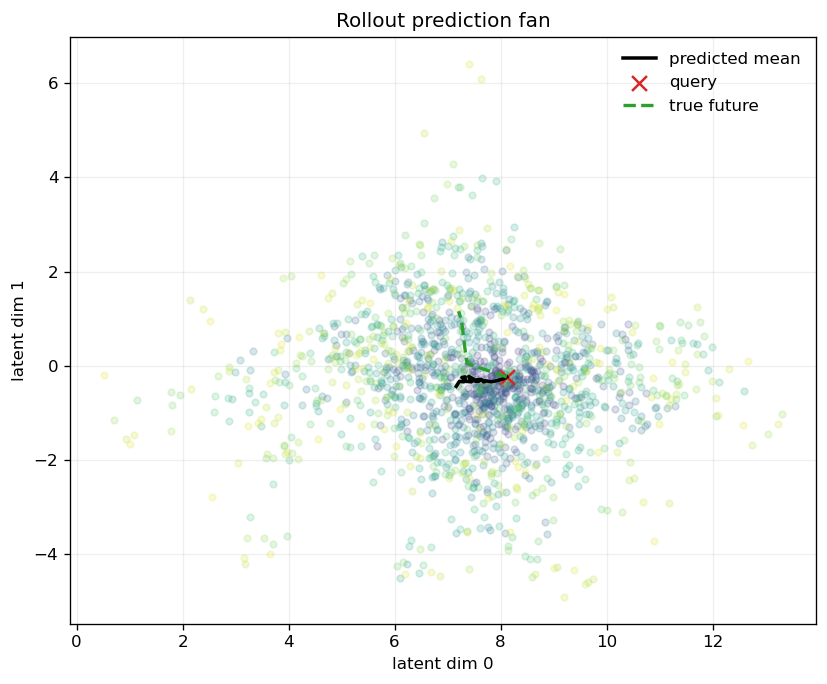

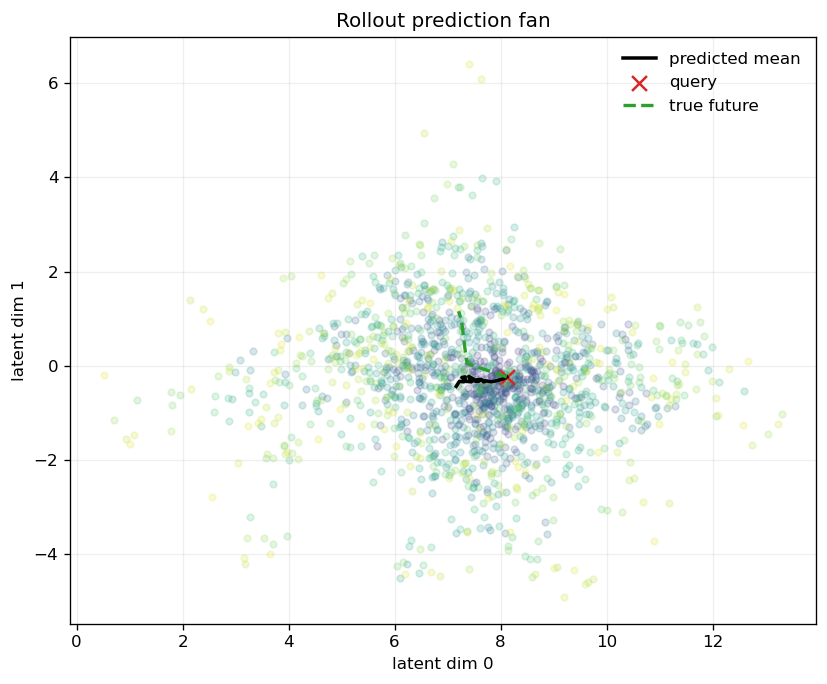

In [72]:
import dev.particle_prediction.viz.prediction as prediction_viz
importlib.reload(prediction_viz)
from dev.particle_prediction.viz.prediction import plot_prediction_fan, plot_rollout_against_truth

plot_prediction_fan(history_query.current_state, rollout, true_future=true_future)

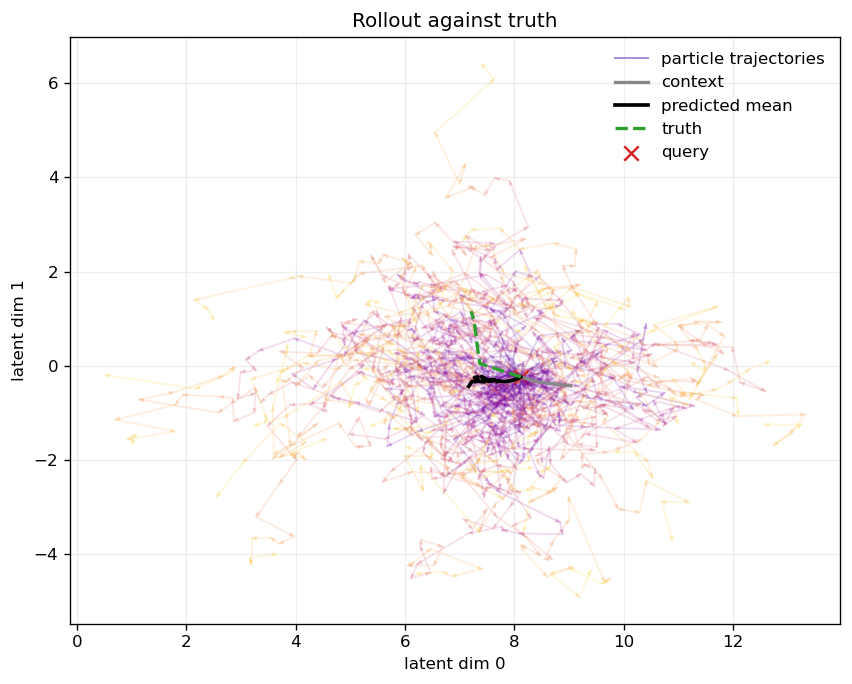

/net/trapnell/vol1/home/nlammers/micromamba/envs/morphseq-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


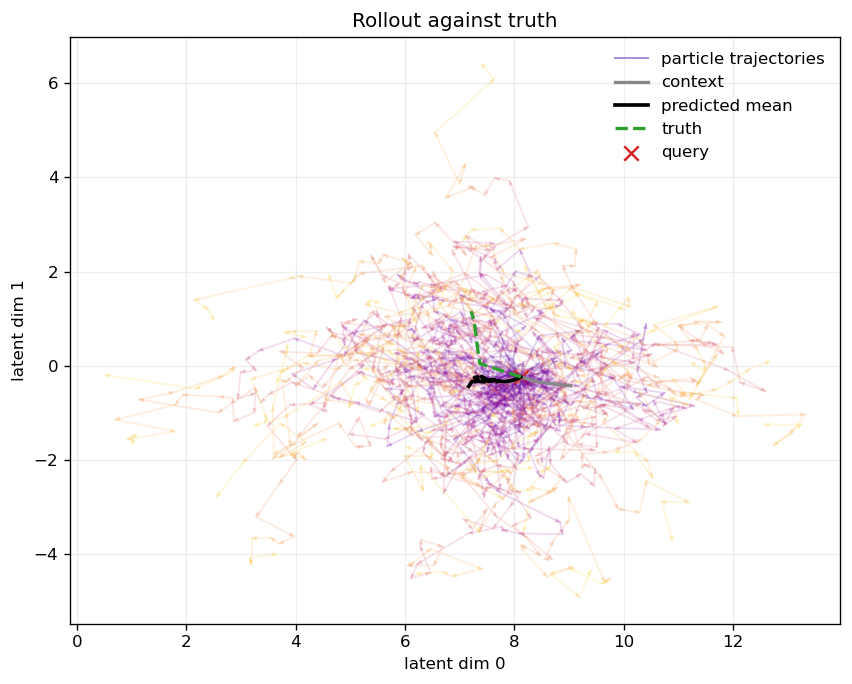

In [73]:
plot_rollout_against_truth(history_query.current_state, rollout, true_future=true_future, context_points=context_points)


In [ ]:
plot_support_diagnostics_along_rollout(rollout)


## Real-Data QC Questions

- Does the held-out embryo live in a sparse part of latent space where the candidate pool becomes weak?
- Are the selected neighbors biologically plausible, or are they matching to obvious artifacts?
- Does the rollout drift off-manifold or simply follow the wrong branch?
